In [1]:
import os
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d
from scipy.interpolate import PchipInterpolator
pd.set_option("display.float_format", lambda x: f"{x:.4f}")


SIM_BASE = "./simulation/Table3"
EVAL_BASE = "./evaluation"
OBS_PATH = "./observed/observed_data_cleaned_deduplicated.csv"
eval_running = "Table3"


# Calculate evaluation metrics and summary statistics

In [2]:

# ============================================================
# Helper: AUC with linear-up/log-down rule
# ============================================================
def calc_auc(time, conc):
    auc = 0.0
    for i in range(len(time) - 1):
        t1, t2 = time[i], time[i+1]
        c1, c2 = conc[i], conc[i+1]

        if c2 > c1:  # linear up
            auc += (c1 + c2) / 2 * (t2 - t1)
        else:        # log down
            if c1 > 0 and c2 > 0 and c1 != c2:
                auc += (c1 - c2) / np.log(c1 / c2) * (t2 - t1)
            else:
                auc += (c1 + c2) / 2 * (t2 - t1)
    return auc


# ============================================================
# Helper: Evaluate one compound
# folds: tuple/list of fold thresholds for coverage metrics
# ============================================================
def evaluate_one_compound(obs_df_c, sim_df_c, folds=(2, 3, 5, 10)):

    cid = obs_df_c["compound_id"].iloc[0]

    # ---------- interpolate simulated concentrations to observed sampling times ----------
    f = PchipInterpolator(sim_df_c["Time_hr"], sim_df_c["mean"])
    pred = f(obs_df_c["Time_hr"].values)

    obs = obs_df_c["Conc_mgl"].values
    time = obs_df_c["Time_hr"].values

    # Remove non-positive
    mask = (pred > 0) & (obs > 0)
    pred = pred[mask]
    obs = obs[mask]
    time = time[mask]

    # ---------- point-wise log2 errors ----------
    log2_ratio = np.log2(pred / obs)
    rel_log2 = np.mean(log2_ratio)
    abs_log2 = np.mean(np.abs(log2_ratio))

    # ---------- Cmax ----------
    cmax_pred = np.max(pred)
    cmax_obs  = np.max(obs)
    fe_cmax_rel = np.log2(cmax_pred / cmax_obs)     # direction (bias)
    fe_cmax_abs = np.abs(fe_cmax_rel)               # magnitude

    # ---------- AUC ----------
    auc_pred = calc_auc(time, pred)
    auc_obs  = calc_auc(time, obs)
    fe_auc_rel = np.log2(auc_pred / auc_obs)
    fe_auc_abs = np.abs(fe_auc_rel)

    # ---------- Tmax difference ----------
    tmax_pred = time[np.argmax(pred)]
    tmax_obs  = time[np.argmax(obs)]
    delta_tmax = tmax_pred - tmax_obs

    # ---------- Within X-fold coverage metrics ----------
    # Use absolute log2 error to determine whether values are within each fold threshold
    coverage = {}
    abs_log2_point = np.abs(log2_ratio)

    for fold in folds:
        thr = np.log2(fold)

        # 1) Time-point coverage: fraction of observed time points within each fold threshold
        pct_time_within = np.mean(abs_log2_point <= thr)  # range 0-1
        coverage[f"time_within_{fold}fold"] = pct_time_within

        # 2) Cmax coverage：compound-level 0/1
        coverage[f"cmax_within_{fold}fold"] = float(fe_cmax_abs <= thr)

        # 3) AUC coverage：compound-level 0/1
        coverage[f"auc_within_{fold}fold"] = float(fe_auc_abs <= thr)

    # ---------- assemble result ----------
    result = {
        "compound_id": cid,
        "rel_log2": rel_log2,
        "abs_log2": abs_log2,
        "fe_cmax_rel": fe_cmax_rel,
        "fe_cmax_abs": fe_cmax_abs,
        "fe_auc_rel": fe_auc_rel,
        "fe_auc_abs": fe_auc_abs,
        "delta_tmax": delta_tmax,
    }

    # Add coverage fields to the result dictionary
    result.update(coverage)
    return result


“PCHIP preserves monotonicity and the shape of the data, avoiding overshoot.
It is recommended for scientific datasets where spline oscillation is undesirable.”

In [3]:
# ============================================================
# Main Pipeline
# ============================================================

# ------------------ Load Observed ---------------------------
obs_df = pd.read_csv(OBS_PATH)
obs_df["Conc_mgl"] = obs_df["Conc_ng_ml"] / 1000
obs_df = obs_df[obs_df["Conc_mgl"] > 0]
obs_df = obs_df.sort_values(["compound_id", "Time_hr"])

# ============================================================
# Loop through simulation folders
# ============================================================

all_results = [] 

for scenario in os.listdir(SIM_BASE):
    scenario_path = os.path.join(SIM_BASE, scenario)
    ct_file = os.path.join(scenario_path, "ct_wide_all.xlsx")

    if not os.path.isfile(ct_file):
        continue  # skip folders without ct_wide_all.xlsx

    print(f"Processing scenario: {scenario}")

    sim_df = pd.read_excel(ct_file)
    sim_df = sim_df[sim_df["mean"] > 0]
    sim_df = sim_df.sort_values(["compound_id", "Time_hr"])

    # Filter observed to only compounds present in simulation
    obs_use = obs_df[obs_df["compound_id"].isin(sim_df["compound_id"].unique())]

    # Evaluate
    results = []
    for cid, obs_df_c in obs_use.groupby("compound_id"):
        sim_df_c = sim_df[sim_df["compound_id"] == cid]
        res = evaluate_one_compound(obs_df_c, 
                                    sim_df_c,
                                    folds=(2,3,5,10))
        results.append(res)

    results_df = pd.DataFrame(results)

    # Save output
    out_dir = os.path.join(EVAL_BASE, eval_running)
    os.makedirs(out_dir, exist_ok=True)
    out_file = os.path.join(out_dir, f"{scenario}_evaluation_summary.csv")
    results_df.to_csv(out_file, index=False)

    print(f"Finished: {scenario} → {out_file}")

    # Add scenario name to results
    results_df["scenario"] = scenario
    
    
    # Store for overall summary later
    all_results.append(results_df)
    
    
print("All scenarios processed.")


Processing scenario: v4_ML
Finished: v4_ML → ./evaluation/Table3/v4_ML_evaluation_summary.csv
Processing scenario: v1_control_minimal
Finished: v1_control_minimal → ./evaluation/Table3/v1_control_minimal_evaluation_summary.csv
Processing scenario: v3_CLsys
Finished: v3_CLsys → ./evaluation/Table3/v3_CLsys_evaluation_summary.csv
Processing scenario: v2_CLint
Finished: v2_CLint → ./evaluation/Table3/v2_CLint_evaluation_summary.csv
Processing scenario: v0_baseline_simcyp
Finished: v0_baseline_simcyp → ./evaluation/Table3/v0_baseline_simcyp_evaluation_summary.csv
All scenarios processed.


In [4]:
# ============================================================
# Overall Summary Across Scenarios
# ============================================================

if len(all_results) > 0:
    overall_df = pd.concat(all_results, ignore_index=True)

    # ----- 1. Summary by scenario (mean/median/std + coverage) -----
    scenario_summary = (
        overall_df
        .groupby("scenario")
        .agg({
            # curve-level
            "rel_log2": ["mean", "median", "std"],
            "abs_log2": ["mean", "median", "std"],
            # Cmax / AUC FE
            "fe_cmax_rel": ["mean", "median", "std"],
            "fe_cmax_abs": ["mean", "median", "std"],
            "fe_auc_rel":  ["mean", "median", "std"],
            "fe_auc_abs":  ["mean", "median", "std"],
            "delta_tmax":  ["mean", "median", "std"],
            # coverage (all are proportions 0–1)
            "time_within_2fold": ["mean"],
            "time_within_3fold": ["mean"],
            "time_within_5fold": ["mean"],
            "time_within_10fold": ["mean"],
            "cmax_within_2fold": ["mean"],
            "cmax_within_3fold": ["mean"],
            "cmax_within_5fold": ["mean"],
            "cmax_within_10fold": ["mean"],
            "auc_within_2fold":  ["mean"],
            "auc_within_3fold":  ["mean"],
            "auc_within_5fold":  ["mean"],
            "auc_within_10fold": ["mean"],
        })
    )

    scenario_summary.columns = [
        "_".join(col).rstrip("_") for col in scenario_summary.columns
    ]
    scenario_summary = scenario_summary.reset_index()

    # ----- 2. Summary by metric (boxplot-ready format) -----
    long_format = overall_df.melt(
        id_vars=["compound_id", "scenario"],
        value_vars=[
            "rel_log2", "abs_log2",
            "fe_cmax_rel", "fe_cmax_abs",
            "fe_auc_rel",  "fe_auc_abs"
        ],
        var_name="metric",
        value_name="value"
    )

    # ----- Create output folder -----
    overall_out = os.path.join(EVAL_BASE, eval_running, "overall")
    os.makedirs(overall_out, exist_ok=True)

    # ----- Save files with 4 decimal places -----
    scenario_summary.to_csv(
        os.path.join(overall_out, "evaluation_summary_by_scenario.csv"),
        index=False, float_format="%.4f"
    )
    long_format.to_csv(
        os.path.join(overall_out, "evaluation_long_format.csv"),
        index=False, float_format="%.4f"
    )
    overall_df.to_csv(
        os.path.join(overall_out, "evaluation_all_raw.csv"),
        index=False, float_format="%.4f"
    )

    print("\n===== Overall Summary Saved =====")
    print(f"Scenario summary → {overall_out}/evaluation_summary_by_scenario.csv")
    print(f"Long-format data → {overall_out}/evaluation_long_format.csv")
    print(f"Raw combined data → {overall_out}/evaluation_all_raw.csv")

   

else:
    print("No scenario results collected.")



===== Overall Summary Saved =====
Scenario summary → ./evaluation/Table3/overall/evaluation_summary_by_scenario.csv
Long-format data → ./evaluation/Table3/overall/evaluation_long_format.csv
Raw combined data → ./evaluation/Table3/overall/evaluation_all_raw.csv


In [5]:
overall_df.scenario.unique()

array(['v4_ML', 'v1_control_minimal', 'v3_CLsys', 'v2_CLint',
       'v0_baseline_simcyp'], dtype=object)

In [6]:
scenario_summary.columns

Index(['scenario', 'rel_log2_mean', 'rel_log2_median', 'rel_log2_std',
       'abs_log2_mean', 'abs_log2_median', 'abs_log2_std', 'fe_cmax_rel_mean',
       'fe_cmax_rel_median', 'fe_cmax_rel_std', 'fe_cmax_abs_mean',
       'fe_cmax_abs_median', 'fe_cmax_abs_std', 'fe_auc_rel_mean',
       'fe_auc_rel_median', 'fe_auc_rel_std', 'fe_auc_abs_mean',
       'fe_auc_abs_median', 'fe_auc_abs_std', 'delta_tmax_mean',
       'delta_tmax_median', 'delta_tmax_std', 'time_within_2fold_mean',
       'time_within_3fold_mean', 'time_within_5fold_mean',
       'time_within_10fold_mean', 'cmax_within_2fold_mean',
       'cmax_within_3fold_mean', 'cmax_within_5fold_mean',
       'cmax_within_10fold_mean', 'auc_within_2fold_mean',
       'auc_within_3fold_mean', 'auc_within_5fold_mean',
       'auc_within_10fold_mean'],
      dtype='object')

>“We ranked parameterisation strategies primarily by the median Absolute Log2 Error across compounds, in line with Geci et al. (2024). Strategies with low median Absolute Log2 Error, low bias (median Relative Log2 Error close to zero), and small Cmax and AUC fold-errors were considered preferable. Additionally, we examined the proportion of compounds predicted within 2-fold for Cmax and AUC as a global coverage measure.”

>“We separated directional bias (relative log₂ fold errors) from error magnitude (absolute log₂ fold errors) consistently for both full concentration–time profiles and key PK metrics (Cmax and AUC), to avoid cancellation effects and enable robust ranking of simulation scenarios.”

In [7]:
 # quick view of key metrics
scenario_summary[
        ["scenario",
            "abs_log2_median",
            "fe_cmax_abs_median",
            "fe_auc_abs_median",
            "time_within_2fold_mean",
            "cmax_within_2fold_mean",
            "auc_within_2fold_mean"]
    ]


,scenario,abs_log2_median,fe_cmax_abs_median,fe_auc_abs_median,time_within_2fold_mean,cmax_within_2fold_mean,auc_within_2fold_mean
0,v0_baseline_simcyp,0.6373,0.4551,0.2831,0.7670,0.7561,0.8780
1,v1_control_minimal,0.7467,0.4949,0.3709,0.7492,0.7073,0.8049
2,v2_CLint,0.8925,0.4679,0.6208,0.6592,0.6829,0.7561
3,v3_CLsys,1.0345,0.6779,0.8909,0.5259,0.6829,0.6098
4,v4_ML,1.0318,0.9103,0.7918,0.5106,0.5610,0.5854


In [8]:
# ============================================================
# Scenario ranking
# ============================================================

sc = scenario_summary.copy()

# ---- 1. Generate ranks for each metric ----
# Error metrics: smaller is better -> ascending=True
sc["rk_abslog2"]   = sc["abs_log2_median"].rank(method="average", ascending=True)
sc["rk_fe_auc"]    = sc["fe_auc_abs_median"].rank(method="average", ascending=True)
sc["rk_fe_cmax"]   = sc["fe_cmax_abs_median"].rank(method="average", ascending=True)

# Coverage metrics: larger is better -> ascending=False
sc["rk_time2"]     = sc["time_within_2fold_mean"].rank(method="average", ascending=False)
sc["rk_auc2"]      = sc["auc_within_2fold_mean"].rank(method="average", ascending=False)
sc["rk_cmax2"]     = sc["cmax_within_2fold_mean"].rank(method="average", ascending=False)

# ---- 2. Set metric weights (all equal by default) ----
w_abslog2 = 1.0   # overall concentration-time profile error
w_auc      = 1.0   # AUC error
w_cmax     = 1.0   # Cmax error
w_time2    = 1.0   # time-point 2-fold coverage
w_auc2     = 1.0   # AUC 2-fold coverage
w_cmax2    = 1.0   # Cmax 2-fold coverage

# Composite rank score, similar to a Borda count; smaller is better
sc["rank_score"] = (
    w_abslog2 * sc["rk_abslog2"] +
    w_auc     * sc["rk_fe_auc"]   +
    w_cmax    * sc["rk_fe_cmax"]  +
    w_time2   * sc["rk_time2"]    +
    w_auc2    * sc["rk_auc2"]     +
    w_cmax2   * sc["rk_cmax2"]
)

sc = sc.sort_values("rank_score").reset_index(drop=True)

print("\n=== Scenario ranking (lower score is better) ===")
sc[["scenario", "rank_score", "abs_log2_median", "fe_auc_abs_median", "fe_cmax_abs_median", "time_within_2fold_mean", "auc_within_2fold_mean", "cmax_within_2fold_mean"]]


=== Scenario ranking (lower score is better) ===


,scenario,rank_score,abs_log2_median,fe_auc_abs_median,fe_cmax_abs_median,time_within_2fold_mean,auc_within_2fold_mean,cmax_within_2fold_mean
0,v0_baseline_simcyp,6.0000,0.6373,0.2831,0.4551,0.7670,0.8780,0.7561
1,v1_control_minimal,13.0000,0.7467,0.3709,0.4949,0.7492,0.8049,0.7073
2,v2_CLint,17.5000,0.8925,0.6208,0.4679,0.6592,0.7561,0.6829
3,v3_CLsys,25.5000,1.0345,0.8909,0.6779,0.5259,0.6098,0.6829
4,v4_ML,28.0000,1.0318,0.7918,0.9103,0.5106,0.5854,0.5610


In [9]:
sc.to_csv(os.path.join(overall_out, "scenario_summary_key_ranking.csv"),
          index=False, float_format="%.3f")

In [10]:
# Export directional-bias metrics used for scenario-level interpretation.
rel_cols = [
    'scenario',
    'rel_log2_mean', 'rel_log2_median',
    'fe_cmax_rel_mean', 'fe_cmax_rel_median',
    'fe_auc_rel_mean', 'fe_auc_rel_median',
]
sc_key = sc[[c for c in rel_cols if c in sc.columns]].copy()
sc_key.to_csv(os.path.join(overall_out, 'scenario_summary_key_rel.csv'),
              index=False, float_format='%.3f')
sc_key


,scenario,rel_log2_mean,rel_log2_median,fe_cmax_rel_mean,fe_cmax_rel_median,fe_auc_rel_mean,fe_auc_rel_median
0,v0_baseline_simcyp,-0.0282,0.1120,-0.3519,-0.2838,0.0677,0.0960
1,v1_control_minimal,0.2367,0.3514,-0.6728,-0.3966,0.3028,0.2942
2,v2_CLint,0.0198,0.2797,-0.6913,-0.4679,0.2165,0.2180
3,v3_CLsys,0.1888,0.2962,-0.6268,-0.4418,0.2787,0.4619
4,v4_ML,0.0661,-0.0567,-1.0236,-0.7844,0.1687,0.2745


# Compound_level Analysis

## Compound-Level Pairwise Comparison

Binary acceptability is defined using **AUC + Cmax** only. The pairwise scenario comparisons below are supporting diagnostics and no longer define the main outcome grouping.


In [11]:
import pandas as pd
import os

def compare_two_scenarios(df_all,
                          scenario_A,
                          scenario_B,
                          out_dir,
                          thr_auc=1.0,
                          thr_cmax=1.0):
    """
    Compare two simulation scenarios at the compound level.
    Binary acceptability is defined only by AUC and Cmax:
        good = (AUC within 2-fold) AND (Cmax within 2-fold)

    abs_log2 is retained as a descriptive field but is not used in the
    binary outcome classification.
    """

    df_A = df_all[df_all["scenario"] == scenario_A].copy()
    df_B = df_all[df_all["scenario"] == scenario_B].copy()

    if df_A.empty:
        raise ValueError(f"Scenario A '{scenario_A}' not found in df_all.")
    if df_B.empty:
        raise ValueError(f"Scenario B '{scenario_B}' not found in df_all.")

    df_A = df_A.set_index("compound_id")
    df_B = df_B.set_index("compound_id")
    df_compare = df_A.add_suffix("_A").join(df_B.add_suffix("_B"))

    df_compare["good_auc_A"] = df_compare["fe_auc_abs_A"] <= thr_auc
    df_compare["good_auc_B"] = df_compare["fe_auc_abs_B"] <= thr_auc
    df_compare["good_cmax_A"] = df_compare["fe_cmax_abs_A"] <= thr_cmax
    df_compare["good_cmax_B"] = df_compare["fe_cmax_abs_B"] <= thr_cmax
    df_compare["good_A"] = df_compare["good_auc_A"] & df_compare["good_cmax_A"]
    df_compare["good_B"] = df_compare["good_auc_B"] & df_compare["good_cmax_B"]

    df_compare["delta_abs_log2_B_minus_A"] = df_compare["abs_log2_B"] - df_compare["abs_log2_A"]
    df_compare["delta_auc_abs_B_minus_A"] = df_compare["fe_auc_abs_B"] - df_compare["fe_auc_abs_A"]
    df_compare["delta_cmax_abs_B_minus_A"] = df_compare["fe_cmax_abs_B"] - df_compare["fe_cmax_abs_A"]

    def classify(row):
        if row["good_A"] and row["good_B"]:
            return "Both acceptable"
        elif row["good_A"] and not row["good_B"]:
            return f"Prefer {scenario_A}"
        elif row["good_B"] and not row["good_A"]:
            return f"Prefer {scenario_B}"
        else:
            return "Refinement"

    df_compare["class"] = df_compare.apply(classify, axis=1)

    os.makedirs(out_dir, exist_ok=True)
    out_path = os.path.join(out_dir, f"compound_classification_{scenario_A}_vs_{scenario_B}.csv")
    df_compare.to_csv(out_path, float_format="%.4f")

    summary = (
        df_compare["class"]
        .value_counts()
        .rename_axis("class")
        .reset_index(name="n")
    )
    summary.to_csv(
        os.path.join(out_dir, f"compound_classification_{scenario_A}_vs_{scenario_B}_summary.csv"),
        index=False
    )

    print(f"\nSaved compound-level classification → {out_path}")
    print(df_compare["class"].value_counts())

    return df_compare


### CL comparison: v2 vs. v3

In [12]:
# overall_df = pd.read_csv(f"./{overall_out}/evaluation_all_raw.csv")
df_all = overall_df

scenario_A = "v2_CLint"
scenario_B = "v3_CLsys"

df_compare_cl = compare_two_scenarios(
    df_all=df_all,
    scenario_A=scenario_A,
    scenario_B=scenario_B,
    out_dir=overall_out,
    thr_auc=1.0,
    thr_cmax=1.0
)



Saved compound-level classification → ./evaluation/Table3/overall/compound_classification_v2_CLint_vs_v3_CLsys.csv
class
Refinement         15
Both acceptable    14
Prefer v2_CLint     7
Prefer v3_CLsys     5
Name: count, dtype: int64


In [13]:
df_compare_cl[df_compare_cl['class'] == 'Refinement']

,rel_log2_A,abs_log2_A,fe_cmax_rel_A,fe_cmax_abs_A,fe_auc_rel_A,fe_auc_abs_A,delta_tmax_A,time_within_2fold_A,cmax_within_2fold_A,auc_within_2fold_A,...,good_auc_A,good_auc_B,good_cmax_A,good_cmax_B,good_A,good_B,delta_abs_log2_B_minus_A,delta_auc_abs_B_minus_A,delta_cmax_abs_B_minus_A,class
compound_id,,,,,,,,,,,,,,,,,,,,,
177,-0.2672,0.9521,-3.1070,3.1070,0.1000,0.1000,0.0000,0.6471,0.0000,1.0000,...,True,True,False,False,False,False,0.2871,0.7437,-0.3907,Refinement
308,0.6173,0.8532,-1.3745,1.3745,0.8477,0.8477,0.0000,0.4615,0.0000,1.0000,...,True,True,False,False,False,False,-0.1097,-0.8437,1.7026,Refinement
323,0.6451,1.3031,-1.0353,1.0353,1.7927,1.7927,142.2000,0.7143,0.0000,0.0000,...,False,False,False,True,False,False,1.1118,1.3923,-1.0147,Refinement
413,1.0860,2.0280,-2.0453,2.0453,0.0949,0.0949,0.4464,0.2000,0.0000,1.0000,...,True,True,False,False,False,False,0.6577,0.8275,0.4344,Refinement
471,-1.8644,1.8644,-0.5362,0.5362,-1.2284,1.2284,0.0000,0.5000,1.0000,0.0000,...,False,True,True,False,False,False,-1.2414,-0.5357,1.2004,Refinement
674,-0.4236,1.0360,-1.4926,1.4926,-0.0391,0.0391,0.0000,0.6429,0.0000,1.0000,...,True,False,False,True,False,False,0.2201,1.3823,-1.0868,Refinement
787,-1.8359,1.8359,-1.0434,1.0434,-0.9319,0.9319,0.0000,0.4545,0.0000,1.0000,...,True,False,False,False,False,False,1.8544,1.1178,0.2969,Refinement
832,0.2694,1.4353,-1.5263,1.5263,-0.4775,0.4775,-0.0947,0.7333,0.0000,1.0000,...,True,False,False,False,False,False,0.8283,0.9543,1.0414,Refinement
938,0.1850,0.5561,-1.5853,1.5853,0.4186,0.4186,0.3077,0.9474,0.0000,1.0000,...,True,False,False,True,False,False,1.4606,1.7048,-1.1321,Refinement


### control comparions: v0 vs v1

In [14]:
df_all = overall_df

scenario_A = "v0_baseline_simcyp"
scenario_B = "v1_control_minimal"

df_compare_control = compare_two_scenarios(
    df_all=df_all,
    scenario_A=scenario_A,
    scenario_B=scenario_B,
    out_dir=overall_out,
    thr_auc=1.0,
    thr_cmax=1.0
)



Saved compound-level classification → ./evaluation/Table3/overall/compound_classification_v0_baseline_simcyp_vs_v1_control_minimal.csv
class
Both acceptable              23
Refinement                    9
Prefer v0_baseline_simcyp     7
Prefer v1_control_minimal     2
Name: count, dtype: int64


In [15]:
# Supporting overlap table between the CL-strategy comparison and the baseline/control comparison
compare_overlap = (
    df_compare_cl[["class", "good_A", "good_B"]]
    .rename(columns={
        "class": "class_compare_ct",
        "good_A": "good_v2",
        "good_B": "good_v3",
    })
    .merge(
        df_compare_control[["class", "good_B"]].rename(columns={
            "class": "class_compare_control",
            "good_B": "good_control_minimal",
        }),
        left_index=True,
        right_index=True,
        how="outer"
    )
    .reset_index()
)

meta_path = "../explore/results/pbpk_physchem_mechanistic_master.csv"
if os.path.exists(meta_path):
    meta = pd.read_csv(meta_path)[["ID_trend_pbpk", "PUBCHEM_CID", "Name_final", "ECCS_new", "clearance_group"]].rename(
        columns={"ID_trend_pbpk": "compound_id"}
    )
    compare_overlap = compare_overlap.merge(meta, on="compound_id", how="left")

compare_overlap["persistent_unacceptable"] = (
    (compare_overlap["class_compare_ct"] == "Refinement")
    & (compare_overlap["class_compare_control"] == "Refinement")
)

compare_overlap.to_csv(
    os.path.join(overall_out, "compound_classification_overlap_ct_vs_control.csv"),
    index=False
)
compare_overlap.head()


,compound_id,class_compare_ct,good_v2,good_v3,class_compare_control,good_control_minimal,PUBCHEM_CID,Name_final,ECCS_new,clearance_group,persistent_unacceptable
0,52,Both acceptable,True,True,Both acceptable,True,2118.0000,alprazolam,Class2,Metabolism-leaning,False
1,172,Both acceptable,True,True,Both acceptable,True,71733.0000,bufuralol,Class2,Mixed/Other,False
2,177,Refinement,False,False,Refinement,False,644073.0000,buprenorphine,Class2,Metabolism-leaning,True
3,184,Both acceptable,True,True,Both acceptable,True,2519.0000,caffeine,Class2,Mixed/Other,False
4,295,Prefer v2_CLint,True,False,Both acceptable,True,84029.0000,clarithromycin,Class4,Metabolism-leaning,False


In [16]:
compare_overlap.class_compare_ct.value_counts()


class_compare_ct
Refinement         15
Both acceptable    14
Prefer v2_CLint     7
Prefer v3_CLsys     5
Name: count, dtype: int64

In [17]:
compare_overlap.class_compare_control.value_counts()


class_compare_control
Both acceptable              23
Refinement                    9
Prefer v0_baseline_simcyp     7
Prefer v1_control_minimal     2
Name: count, dtype: int64

In [18]:
df_compare_merge = df_compare_cl.merge(df_compare_control[["class"]].rename(columns={"class": "class_control"}), left_index=True, right_index=True, how="left" )
crosstab_compare_control_cl = pd.crosstab(df_compare_merge['class'], df_compare_merge['class_control'], dropna=False)
print(crosstab_compare_control_cl)
crosstab_compare_control_cl.to_csv(os.path.join(overall_out, "crosstab_compare_control_cl.csv"), index=True)

class_control    Both acceptable  Prefer v0_baseline_simcyp  \
class                                                         
Both acceptable               12                          0   
Prefer v2_CLint                6                          1   
Prefer v3_CLsys                0                          3   
Refinement                     5                          3   

class_control    Prefer v1_control_minimal  Refinement  
class                                                   
Both acceptable                          1           1  
Prefer v2_CLint                          0           0  
Prefer v3_CLsys                          1           1  
Refinement                               0           7  


In [19]:
crosstab_compare_control_cl

class_control,Both acceptable,Prefer v0_baseline_simcyp,Prefer v1_control_minimal,Refinement
class,,,,
Both acceptable,12,0,1,1
Prefer v2_CLint,6,1,0,0
Prefer v3_CLsys,0,3,1,1
Refinement,5,3,0,7


## Outputs for control + cl compare results


In [20]:
df_compare_merge = df_compare_cl.merge(df_compare_control[["class"]].rename(columns={"class": "class_control"}), left_index=True, right_index=True, how="left" )
crosstab_compare_control_cl = pd.crosstab(df_compare_merge['class'], df_compare_merge['class_control'], dropna=False)
print(crosstab_compare_control_cl)
crosstab_compare_control_cl.to_csv(os.path.join(overall_out, "crosstab_compare_control_cl.csv"), index=True)

class_control    Both acceptable  Prefer v0_baseline_simcyp  \
class                                                         
Both acceptable               12                          0   
Prefer v2_CLint                6                          1   
Prefer v3_CLsys                0                          3   
Refinement                     5                          3   

class_control    Prefer v1_control_minimal  Refinement  
class                                                   
Both acceptable                          1           1  
Prefer v2_CLint                          0           0  
Prefer v3_CLsys                          1           1  
Refinement                               0           7  


In [21]:
crosstab_compare_control_cl

class_control,Both acceptable,Prefer v0_baseline_simcyp,Prefer v1_control_minimal,Refinement
class,,,,
Both acceptable,12,0,1,1
Prefer v2_CLint,6,1,0,0
Prefer v3_CLsys,0,3,1,1
Refinement,5,3,0,7


## Scatterplots for control + cl compare results

In [22]:
plot_dir = os.path.join(EVAL_BASE, eval_running, "plot")
os.makedirs(plot_dir, exist_ok=True)

In [23]:
import numpy as np
import matplotlib.pyplot as plt

def add_classification(df_compare, thr_auc=1.0, thr_cmax=1.0):
    ok_A = (df_compare["fe_auc_abs_A"] <= thr_auc) & (df_compare["fe_cmax_abs_A"] <= thr_cmax)
    ok_B = (df_compare["fe_auc_abs_B"] <= thr_auc) & (df_compare["fe_cmax_abs_B"] <= thr_cmax)

    cls = np.where(ok_A & ok_B, "Both acceptable",
          np.where(ok_A & ~ok_B, "Prefer A",
          np.where(~ok_A & ok_B, "Prefer B", "Neither acceptable")))
    out = df_compare.copy()
    out["class"] = cls
    return out

def plot_AB_panels(df_compare, thr_auc=1.0, thr_cmax=1.0, outpath="Figure_AB.png"):
    df_plot = add_classification(df_compare, thr_auc=thr_auc, thr_cmax=thr_cmax)

    palette = {
        "Both acceptable": "#1b9e77",
        "Prefer A":        "#7570b3",
        "Prefer B":        "#d95f02",
        "Neither acceptable":      "#666666",
    }
    order = ["Both acceptable", "Prefer A", "Prefer B", "Neither acceptable"]

    fig, axes = plt.subplots(1, 2, figsize=(8,4), sharex=False, sharey=False)

    def _panel(ax, x_col, y_col, thr, title, xlabel, ylabel, panel_letter):
        handles = []
        labels = []

        for k in order:
            sub = df_plot[df_plot["class"] == k]
            if sub.empty:
                continue
            h = ax.scatter(
                sub[x_col], sub[y_col],
                s=45, alpha=0.85,
                c=palette.get(k, "#333333"),
                edgecolors="white", linewidths=0.6,
                label=f"{k} (n={len(sub)})"
            )
            handles.append(h)
            labels.append(f"{k} (n={len(sub)})")

        ax.axvline(thr, linestyle="--", linewidth=1)
        ax.axhline(thr, linestyle="--", linewidth=1)

        m = float(np.nanmax(df_plot[[x_col, y_col]].values))
        ax.plot([0, m], [0, m], linestyle=":", linewidth=1)

        ax.set_title(title)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.text(0.02, 0.98, panel_letter, transform=ax.transAxes, ha="left", va="top", fontsize=14, fontweight="bold")
        return handles, labels

    h1, l1 = _panel(
        axes[0],
        x_col="fe_cmax_abs_A",
        y_col="fe_cmax_abs_B",
        thr=thr_cmax,
        title="Compound-level comparison (Cmax error)",
        xlabel="Scenario A |log2 FE (Cmax)|",
        ylabel="Scenario B |log2 FE (Cmax)|",
        panel_letter="A"
    )

    h2, l2 = _panel(
        axes[1],
        x_col="fe_auc_abs_A",
        y_col="fe_auc_abs_B",
        thr=thr_auc,
        title="Compound-level comparison (AUC error)",
        xlabel="Scenario A |log2 FE (AUC)|",
        ylabel="Scenario B |log2 FE (AUC)|",
        panel_letter="B"
    )

    fig.legend(h1, l1, loc="center left", bbox_to_anchor=(0.98, 0.8), frameon=False)
    plt.tight_layout(rect=[0, 0, 1, 1])
    fig.savefig(outpath, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved figure → {outpath}")


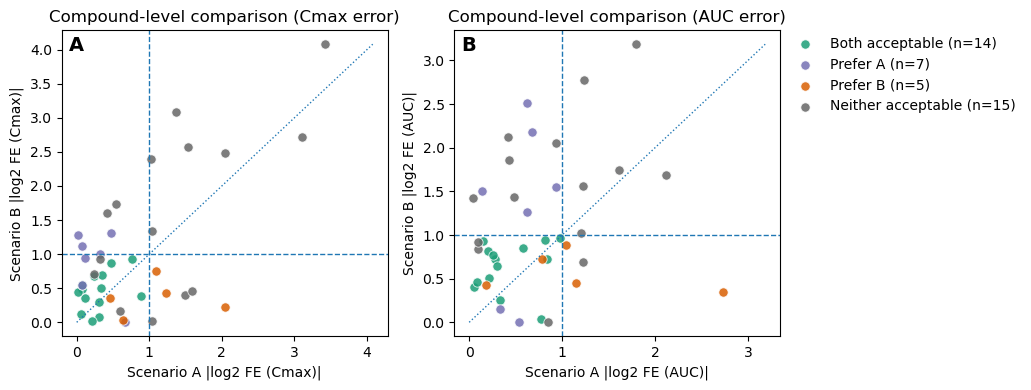

Saved figure → ./evaluation/Table3/plot/compound_level_cl.png


In [24]:
# ===== Usage =====
fig = plot_AB_panels(df_compare_cl, 
                     thr_auc=1.0, 
                     thr_cmax=1.0,
                     outpath=f"{plot_dir}/compound_level_cl.png")


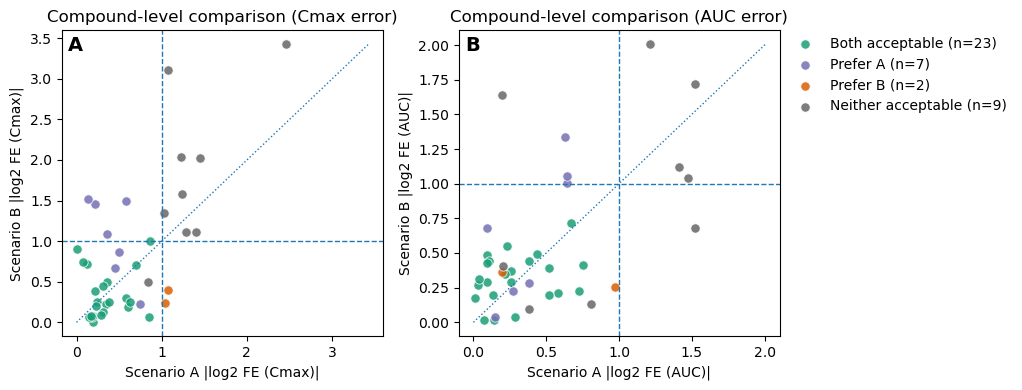

Saved figure → ./evaluation/Table3/plot/compound_level_control.png


In [25]:
# control level plotting 
# ===== Usage =====
fig = plot_AB_panels(df_compare_control, 
                     thr_auc=1.0, 
                     thr_cmax=1.0,
                     outpath=f"{plot_dir}/compound_level_control.png")


##  Figure 5 performance for pbpk eval (CL compare)

/var/folders/c_/l9r4r0jn4l72z8j0s7nk8hhh0000gn/T/ipykernel_13713/2960733639.py:178: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.70, 1])


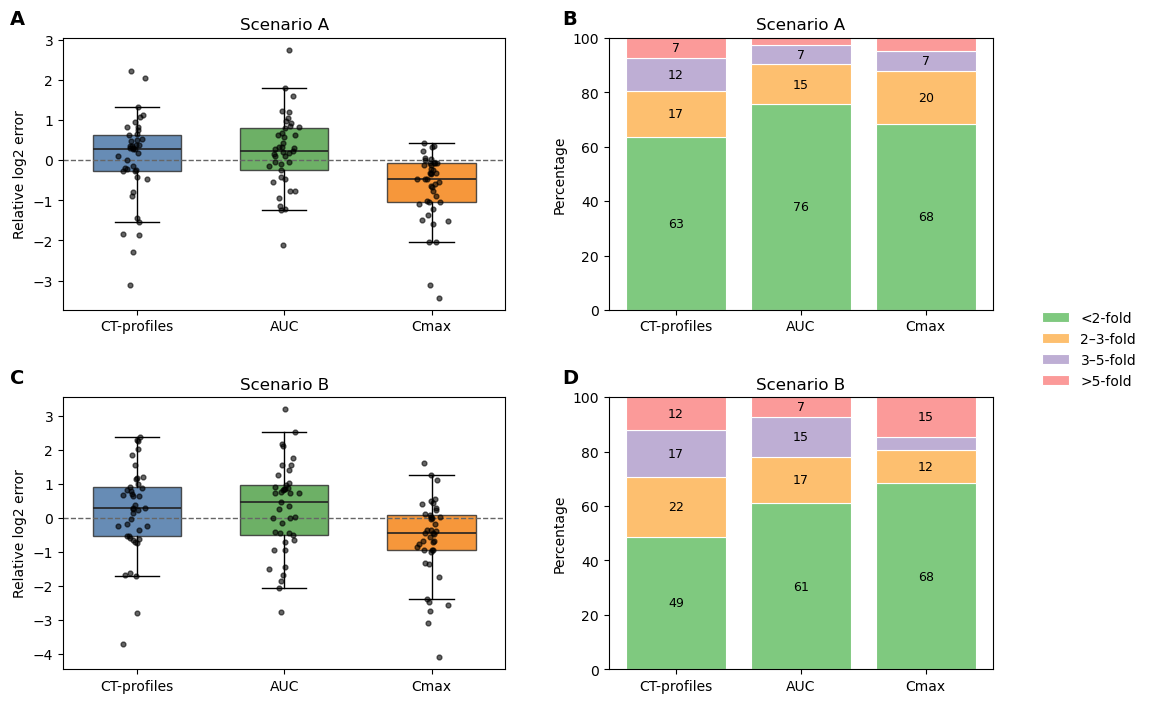

Saved: ./evaluation/Table3/plot/Fig_folderror_ScenarioA_vs_ScenarioB.png


In [26]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# Config
# =========================

scenario_A = "v2_CLint"         # bottom-up CLint/mechanistic clearance workflow
scenario_B = "v3_CLsys"   # systemic-clearance workflow

plot_dir = os.path.join(EVAL_BASE, eval_running, "plot")
os.makedirs(plot_dir, exist_ok=True)
outpath = os.path.join(plot_dir, f"Fig_folderror_ScenarioA_vs_ScenarioB.png")

# Bin thresholds for absolute fold error where FE_abs = |log2(P/O)|
T2 = 1.0
T3 = np.log2(3.0)
T5 = np.log2(5.0)

bins = ["<2-fold", "2–3-fold", "3–5-fold", ">5-fold"]
colors = ["#7fc97f", "#fdbf6f", "#beaed4", "#fb9a99"]  # green, orange, purple, red-ish

# Endpoints labels (more rigorous)
ENDPOINTS = ["CT-profiles", "AUC", "Cmax"]

# Legend placement: move closer to plots by adjusting bbox_to_anchor
LEGEND_BBOX = (0.93, 0.50)  # <-- tweak this (x, y). smaller x brings legend closer

# =========================
# Helpers
# =========================
def _require_cols(df, cols):
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise ValueError(f"overall_df missing columns: {missing}")

def fold_bin_from_log2_abs(x):
    if pd.isna(x):
        return np.nan
    if x < T2:
        return "<2-fold"
    elif x < T3:
        return "2–3-fold"
    elif x < T5:
        return "3–5-fold"
    else:
        return ">5-fold"

def make_fold_coverage_table(df_s, endpoint_label):
    if endpoint_label == "CT-profiles":
        fe_abs = df_s["abs_log2"]
    elif endpoint_label == "AUC":
        fe_abs = df_s["fe_auc_abs"]
    elif endpoint_label == "Cmax":
        fe_abs = df_s["fe_cmax_abs"]
    else:
        raise ValueError("endpoint_label must be one of {'CT-profiles','AUC','Cmax'}")

    cat = fe_abs.apply(fold_bin_from_log2_abs)
    counts = cat.value_counts(dropna=True).reindex(bins, fill_value=0)
    pct = counts / counts.sum() * 100 if counts.sum() > 0 else counts.astype(float)
    return pct

def plot_bias_box(ax, df_s, title):
    # Relative log2 errors (directional bias)
    data = [
        df_s["rel_log2"].dropna().values,         # CT-profiles
        df_s["fe_auc_rel"].dropna().values,       # AUC
        df_s["fe_cmax_rel"].dropna().values,      # Cmax
    ]

    bp = ax.boxplot(
        data,
        labels=ENDPOINTS,
        showfliers=False,
        widths=0.6,
        patch_artist=True
    )

    # clean boxes
    box_colors = ["#4C78A8", "#54A24B", "#F58518"]  # blue/green/orange
    for patch, c in zip(bp["boxes"], box_colors):
        patch.set_facecolor(c)
        patch.set_alpha(0.85)
        patch.set_edgecolor("#333333")
        patch.set_linewidth(1.0)

    for median in bp["medians"]:
        median.set_color("#222222")
        median.set_linewidth(1.2)

    # overlay scatter jitter
    rng = np.random.default_rng(7)
    for i, vals in enumerate(data, start=1):
        if len(vals) == 0:
            continue
        x = rng.normal(i, 0.05, size=len(vals))
        ax.scatter(x, vals, s=12, alpha=0.6, color="black", zorder=3)

    ax.axhline(0, linestyle="--", linewidth=1, color="#666666")
    ax.set_ylabel("Relative log2 error")
    ax.set_title(title)

def plot_fold_stacked(ax, df_s, title):
    # Build % table: rows bins, cols endpoints
    table = pd.DataFrame(index=bins, columns=ENDPOINTS, dtype=float)
    for ep in ENDPOINTS:
        table[ep] = make_fold_coverage_table(df_s, ep)

    bottom = np.zeros(len(ENDPOINTS), dtype=float)
    for b, c in zip(bins, colors):
        vals = table.loc[b, ENDPOINTS].values
        ax.bar(ENDPOINTS, vals, bottom=bottom, color=c, edgecolor="white", linewidth=0.8, label=b)

        # annotate segment with integer %
        for i, v in enumerate(vals):
            if v >= 5:  # label if large enough
                ax.text(i, bottom[i] + v/2, f"{int(round(v))}", ha="center", va="center", fontsize=9)
        bottom += vals

    ax.set_ylim(0, 100)
    ax.set_ylabel("Percentage")
    ax.set_title(title)

# =========================
# Main
# =========================
_require_cols(
    overall_df,
    ["compound_id","scenario","rel_log2","abs_log2","fe_auc_rel","fe_auc_abs","fe_cmax_rel","fe_cmax_abs"]
)

dfA = overall_df[overall_df["scenario"] == scenario_A].copy()
dfB = overall_df[overall_df["scenario"] == scenario_B].copy()

if dfA.empty:
    raise ValueError(f"No rows found for scenario_A='{scenario_A}'")
if dfB.empty:
    raise ValueError(f"No rows found for scenario_B='{scenario_B}'")

# Align compounds (intersection only)
common = np.intersect1d(dfA["compound_id"].unique(), dfB["compound_id"].unique())
dfA = dfA[dfA["compound_id"].isin(common)].copy()
dfB = dfB[dfB["compound_id"].isin(common)].copy()

# =========================
# Figure layout (2x2)
# =========================
fig, axes = plt.subplots(
    2, 2,
    figsize=(12, 8.2),
    gridspec_kw={"width_ratios":[1.15, 1.0], "wspace":0.25, "hspace":0.32}
)
(axA, axB), (axC, axD) = axes

plot_bias_box(axA, dfA, title="Scenario A")
plot_fold_stacked(axB, dfA, title="Scenario A")

plot_bias_box(axC, dfB, title="Scenario B")
plot_fold_stacked(axD, dfB, title="Scenario B")

# Panel labels
for label, ax in zip(["A","B","C","D"], [axA, axB, axC, axD]):
    ax.text(-0.12, 1.05, label, transform=ax.transAxes, fontsize=14, fontweight="bold")

# Shared legend (closer)
handles, labels = axB.get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="center left",
    bbox_to_anchor=LEGEND_BBOX,  # <-- key adjustment
    frameon=False
)

# Tight layout leaving modest space for legend
plt.tight_layout(rect=[0, 0, 0.70, 1])

fig.savefig(outpath, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", outpath)


## Mechanistic Stratification and Response-Letter Figures

This section reproduces the mechanism-oriented analysis used for the revised manuscript and response letter. It starts from the curated master table supplied in this repository (`pbpk_physchem_mechanistic_master.csv`; Data S3 in the manuscript) and does not require access to the original exploratory workspace. The goal is to regenerate the ECCS-based Figure 6 and the response-letter support figures documenting the empirical PBPK input landscape and exploratory mechanistic stratifications.


In [27]:
from pathlib import Path
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
except ImportError as exc:
    raise ImportError("This section requires seaborn for plotting. Install seaborn or run in an environment with seaborn available.") from exc

# Locate the PBPK evaluation repository whether the notebook is launched from
# this folder or from the broader project root.
_candidate_roots = [
    Path.cwd(),
    Path.cwd() / "Table3_data" / "pbpk evaluation repo",
]
REPO_ROOT = next(
    (root for root in _candidate_roots if (root / "pbpk_physchem_mechanistic_master.csv").exists()),
    None,
)
if REPO_ROOT is None:
    raise FileNotFoundError("Could not locate pbpk_physchem_mechanistic_master.csv from the current working directory.")

MASTER_PATH = REPO_ROOT / "pbpk_physchem_mechanistic_master.csv"
MECH_PLOT_DIR = REPO_ROOT / "evaluation" / "Table3" / "plot" / "mechanistic"
MECH_PLOT_DIR.mkdir(parents=True, exist_ok=True)

master = pd.read_csv(MASTER_PATH)

SCENARIO_A = "v2_CLint"
SCENARIO_B = "v3_CLsys"
DELTA_SCORE_CONC = "delta_score_conc_v3_minus_v2"
DELTA_SCORE_AUC = "delta_score_auc_v3_minus_v2"
DELTA_SCORE_CMAX = "delta_score_cmax_v3_minus_v2"
BENEFIT_SCORE_CONC = "v3_benefit_score_conc"
BENEFIT_SCORE_AUC = "v3_benefit_score_auc"
BENEFIT_SCORE_CMAX = "v3_benefit_score_cmax"

required_cols = {
    "PUBCHEM_CID", "ID_trend_pbpk", "Name_final", "class", "ECCS_new",
    "clearance_group", "ionization_group", "logP_bin", "Vd_bin",
    DELTA_SCORE_CONC, DELTA_SCORE_AUC, DELTA_SCORE_CMAX,
}
missing = sorted(required_cols - set(master.columns))
assert not missing, f"Missing required columns in master table: {missing}"

# Benefit scores are used for visualization: positive values favor v3_CLsys.
master[BENEFIT_SCORE_CONC] = -master[DELTA_SCORE_CONC]
master[BENEFIT_SCORE_AUC] = -master[DELTA_SCORE_AUC]
master[BENEFIT_SCORE_CMAX] = -master[DELTA_SCORE_CMAX]

class_order = ["Both acceptable", "Prefer v2_CLint", "Prefer v3_CLsys", "Refinement"]
eccs_new_order = ["Class1", "Class2", "Class3", "Class4"]
clearance_order = ["Metabolism-leaning", "Renal-leaning", "Uptake/Biliary-influenced", "Mixed/Other"]
ionization_order = ["Acidic", "Basic", "Zwitterion", "Multiprotic/Other", "Neutral/Other"]
logp_order = ["<2", "2-4", ">4"]
vd_order = ["Low", "Mid", "High"]

group_specs = [
    ("clearance_group", clearance_order, "Clearance group"),
    ("ionization_group", ionization_order, "Ionization group"),
    ("logP_bin", logp_order, "LogP bin"),
    ("Vd_bin", vd_order, "VDss bin"),
]

master.shape


(41, 79)

### Figure 6: ECCS-Stratified Benefit Scores

This figure is intended for the revised manuscript. The v3 benefit score is defined as the error under the v2_CLint workflow minus the error under the v3_CLsys workflow. Positive values therefore indicate lower error with v3_CLsys, whereas negative values indicate lower error with v2_CLint.


/Users/clement.cai/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/clement.cai/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/clement.cai/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/clement.cai/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_

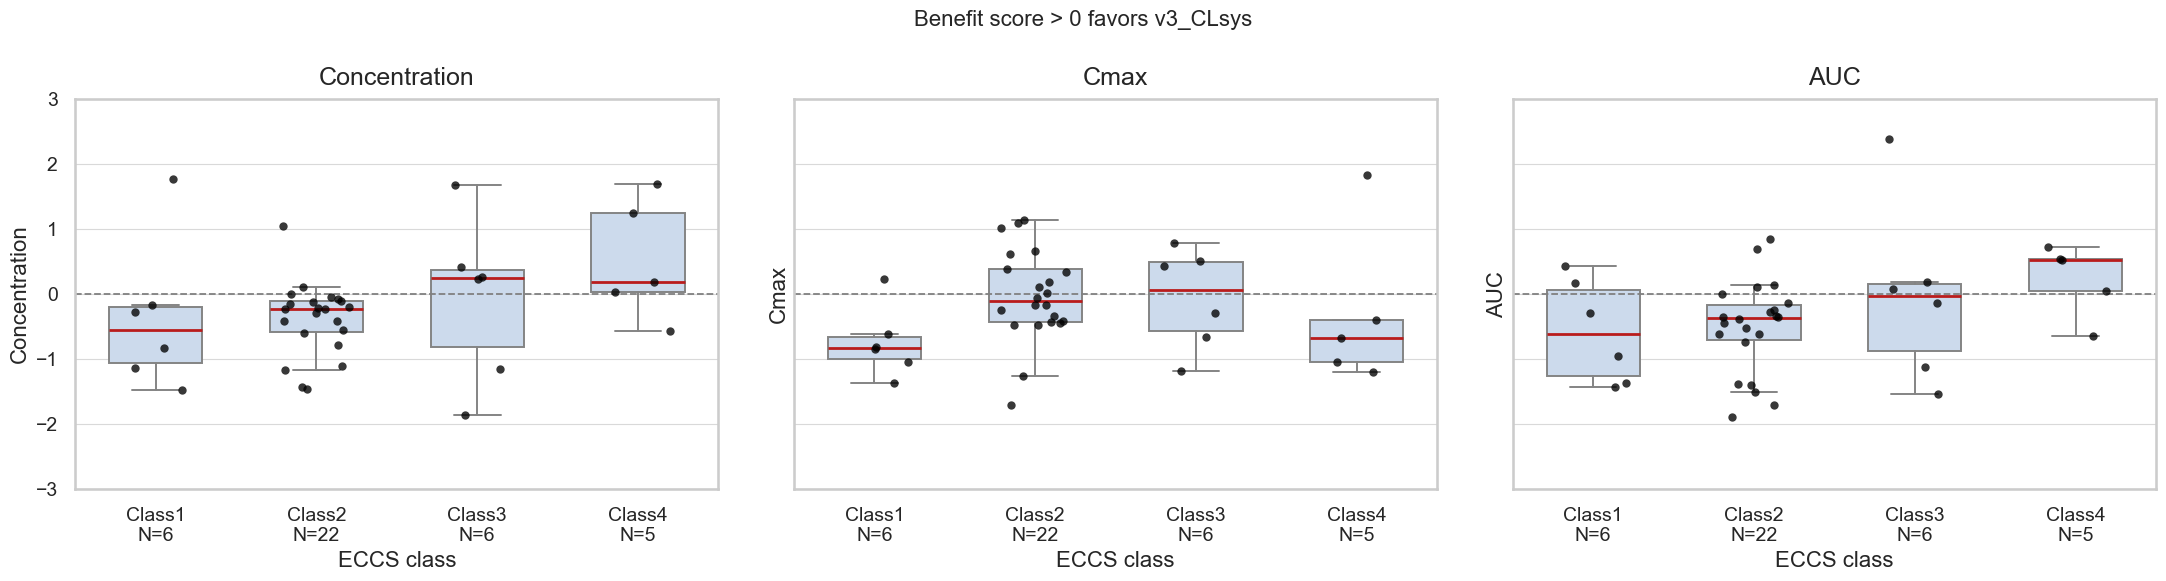

PosixPath('/Users/clement.cai/Documents/New project/Table3_data/pbpk evaluation repo/evaluation/Table3/plot/mechanistic/Figure6_ECCS_v3_benefit_scores.png')

In [33]:
benefit_panels = [
    (BENEFIT_SCORE_CONC, "Concentration", "Concentration"),
    (BENEFIT_SCORE_CMAX, "Cmax", "Cmax"),
    (BENEFIT_SCORE_AUC, "AUC", "AUC"),
]

plot_df = master.dropna(subset=["ECCS_new"]).copy()
plot_cols = [col for col, _, _ in benefit_panels]
ylim_abs = float(np.nanmax(np.abs(plot_df[plot_cols].to_numpy())))
ylim_abs = np.ceil((ylim_abs + 0.15) * 2) / 2
class_counts = plot_df.groupby("ECCS_new", observed=False).size().reindex(eccs_new_order)
xtick_labels = [f"{cls}\nN={int(class_counts.loc[cls])}" for cls in eccs_new_order]

sns.set_theme(style="whitegrid", context="talk")
fig, axes = plt.subplots(1, 3, figsize=(22, 6), sharey=True)

for ax, (metric_col, title, ylabel) in zip(axes, benefit_panels):
    sns.boxplot(
        data=plot_df,
        x="ECCS_new",
        y=metric_col,
        order=eccs_new_order,
        ax=ax,
        color="#c7d9f1",
        width=0.58,
        fliersize=0,
        linewidth=1.4,
        medianprops={"color": "#b91c1c", "linewidth": 2.0},
    )
    sns.stripplot(
        data=plot_df,
        x="ECCS_new",
        y=metric_col,
        order=eccs_new_order,
        ax=ax,
        color="black",
        size=6,
        alpha=0.78,
        jitter=0.22,
    )
    ax.axhline(0, ls="--", c="gray", lw=1.3)
    ax.set_ylim(-ylim_abs, ylim_abs)
    ax.set_title(title, fontsize=18, pad=10)
    ax.set_xlabel("ECCS class", fontsize=16)
    ax.set_ylabel(ylabel, fontsize=16)
    ax.set_xticklabels(xtick_labels, fontsize=14)
    ax.tick_params(axis="y", labelsize=14)
    ax.grid(axis="y", color="#d9d9d9", linewidth=0.8)
    ax.grid(axis="x", visible=False)

fig.text(0.5, 0.98, "Benefit score > 0 favors v3_CLsys", ha="center", va="top", fontsize=16)
plt.tight_layout(rect=(0, 0, 1, 0.93), w_pad=2.0)

out_base = MECH_PLOT_DIR / "Figure6_ECCS_v3_benefit_scores"
fig.savefig(out_base.with_suffix(".png"), dpi=600, bbox_inches="tight")
fig.savefig(out_base.with_suffix(".pdf"), bbox_inches="tight")
plt.show()
plt.close(fig)

out_base.with_suffix(".png")


### Response Figure R2: Empirical PBPK Input Landscape

This response-letter figure visualizes the PBPK-ready evaluation set across empirical input dimensions. It is descriptive and is intended to show that strategy preference was not explained by a single physicochemical or ADME variable alone.


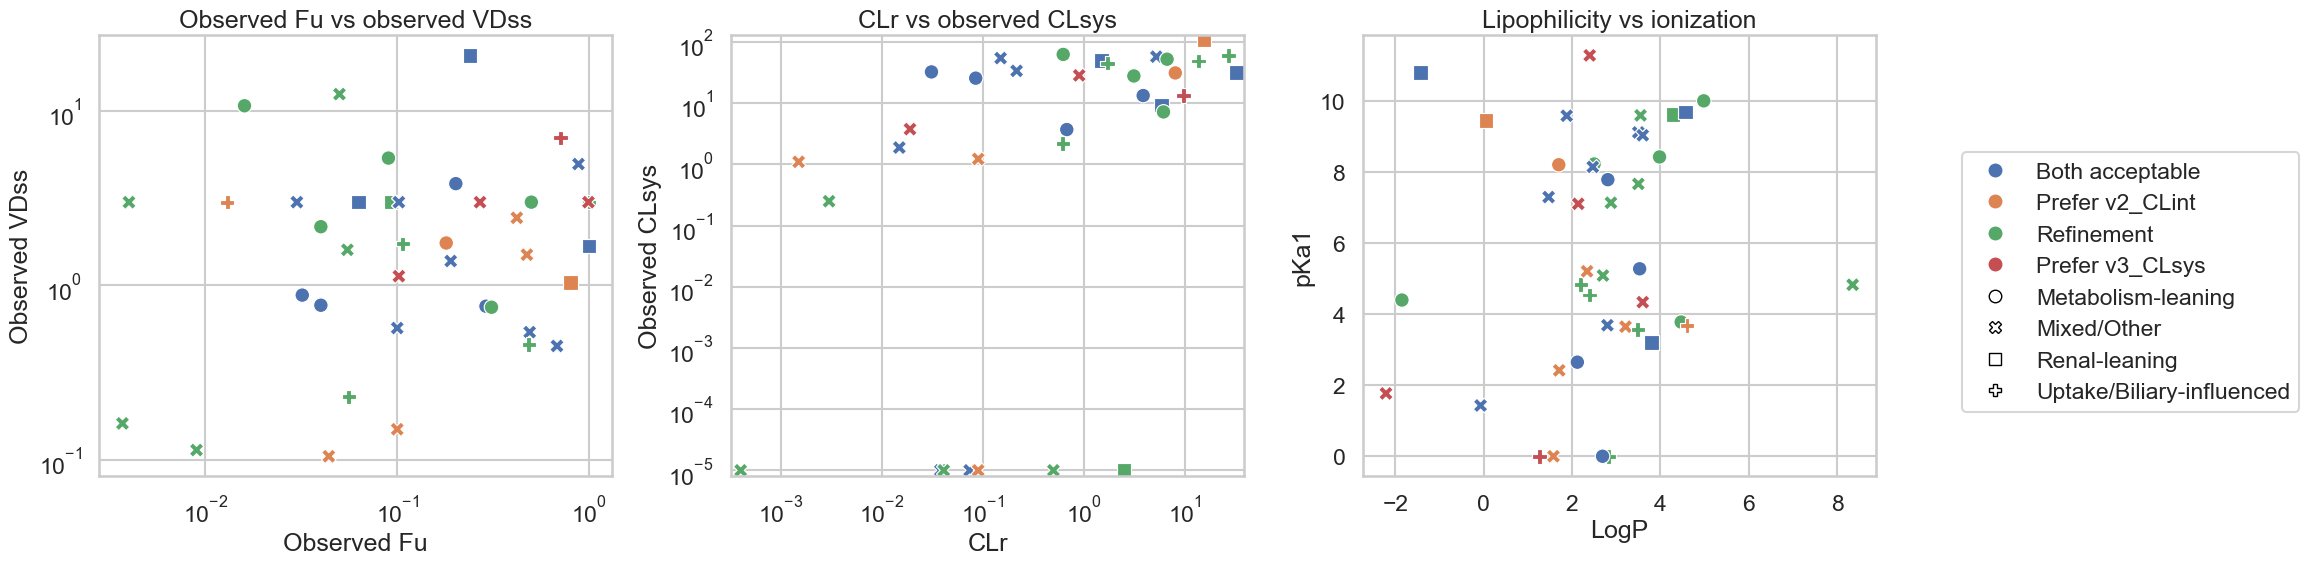

PosixPath('/Users/clement.cai/Documents/New project/Table3_data/pbpk evaluation repo/evaluation/Table3/plot/mechanistic/Response_Figure_R2_empirical_input_landscape.png')

In [34]:
plot_df = master.copy()
cl_obs_col = "CL_MetBas_s2" if "CL_MetBas_s2" in plot_df.columns else "CL_MetBas_key"

class_palette = {
    "Both acceptable": "#4C72B0",
    "Prefer v2_CLint": "#DD8452",
    "Refinement": "#55A868",
    "Prefer v3_CLsys": "#C44E52",
}
clearance_markers = {
    "Metabolism-leaning": "o",
    "Mixed/Other": "X",
    "Renal-leaning": "s",
    "Uptake/Biliary-influenced": "P",
}

plot_df_cl = plot_df[
    plot_df["CLRbase"].notna()
    & plot_df[cl_obs_col].notna()
    & (plot_df["CLRbase"] > 0)
    & (plot_df[cl_obs_col] > 0)
].copy()

fig, axes = plt.subplots(1, 3, figsize=(24, 6))
fig.subplots_adjust(right=0.80, wspace=0.32)

sns.scatterplot(data=plot_df, x="Fu_s2", y="VD_s2", hue="class", style="clearance_group",
                palette=class_palette, markers=clearance_markers, s=110, ax=axes[0], legend=False)
axes[0].set_title("Observed Fu vs observed VDss")
axes[0].set_xlabel("Observed Fu")
axes[0].set_ylabel("Observed VDss")
axes[0].set_xscale("log")
axes[0].set_yscale("log")

sns.scatterplot(data=plot_df_cl, x="CLRbase", y=cl_obs_col, hue="class", style="clearance_group",
                palette=class_palette, markers=clearance_markers, s=110, ax=axes[1], legend=False)
axes[1].set_title("CLr vs observed CLsys")
axes[1].set_xlabel("CLr")
axes[1].set_ylabel("Observed CLsys")
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlim(plot_df_cl["CLRbase"].min() * 0.8, plot_df_cl["CLRbase"].max() * 1.2)
axes[1].set_ylim(plot_df_cl[cl_obs_col].min() * 0.8, plot_df_cl[cl_obs_col].max() * 1.2)

sns.scatterplot(data=plot_df, x="LogP_s2", y="pKa1_key", hue="class", style="clearance_group",
                palette=class_palette, markers=clearance_markers, s=110, ax=axes[2], legend=False)
axes[2].set_title("Lipophilicity vs ionization")
axes[2].set_xlabel("LogP")
axes[2].set_ylabel("pKa1")

class_handles = [
    Line2D([0], [0], marker="o", linestyle="None", markerfacecolor=color,
           markeredgecolor=color, markersize=9, label=label)
    for label, color in class_palette.items()
]
clearance_handles = [
    Line2D([0], [0], marker=marker, linestyle="None", markerfacecolor="white",
           markeredgecolor="black", markersize=9, label=label)
    for label, marker in clearance_markers.items()
]
fig.legend(handles=class_handles + clearance_handles, loc="center left", bbox_to_anchor=(0.82, 0.5), frameon=True)
plt.tight_layout(rect=(0, 0, 0.80, 1))

out_base = MECH_PLOT_DIR / "Response_Figure_R2_empirical_input_landscape"
fig.savefig(out_base.with_suffix(".png"), dpi=600, bbox_inches="tight")
fig.savefig(out_base.with_suffix(".pdf"), bbox_inches="tight")
plt.show()

plt.close(fig)

out_base.with_suffix(".png")


### Response Figure R3: Outcome Composition Across Mechanistic Strata

This response-letter figure summarizes how compound-level outcome categories are distributed across empirical clearance, ionization, lipophilicity, and distribution strata. It supports the conclusion that PBPK strategy preference is multifactorial rather than driven by a single descriptor.


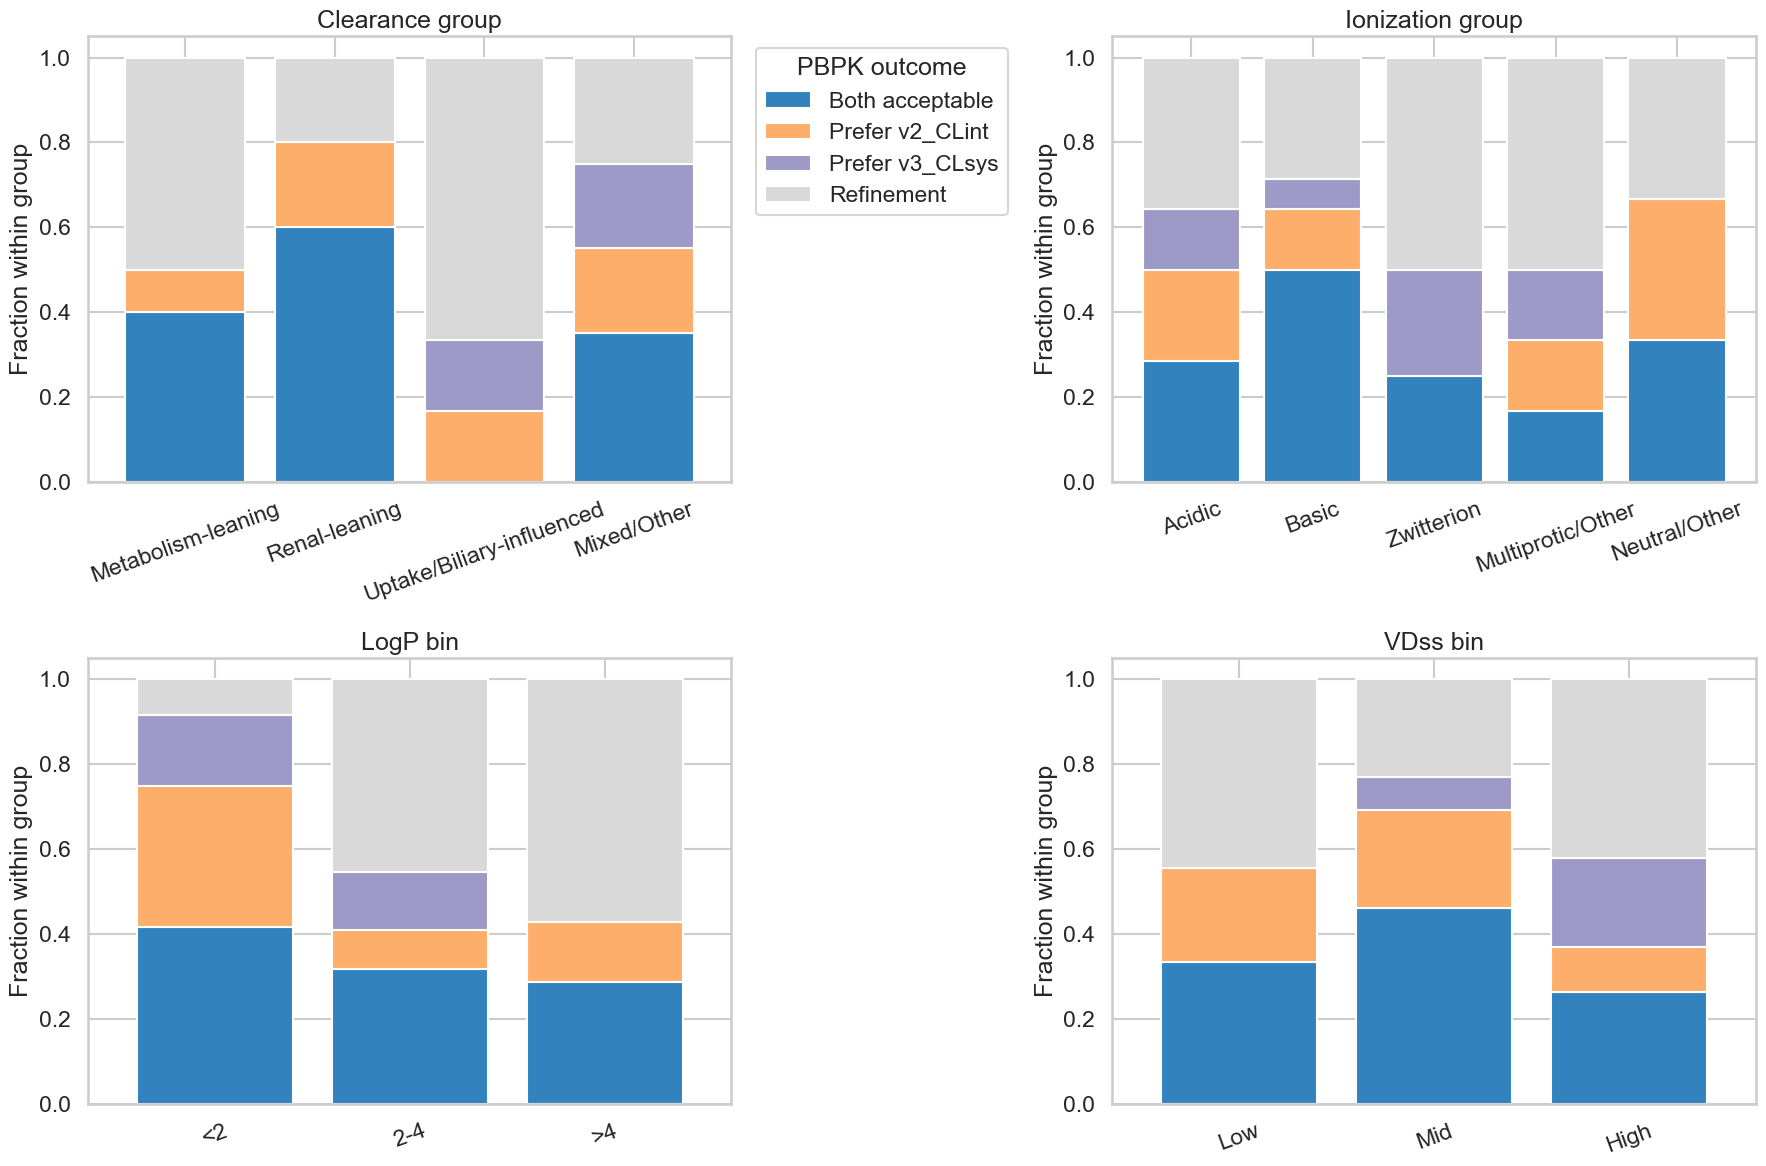

PosixPath('/Users/clement.cai/Documents/New project/Table3_data/pbpk evaluation repo/evaluation/Table3/plot/mechanistic/Response_Figure_R3_outcome_by_mechanistic_strata.png')

In [35]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
for ax, (col, order, title) in zip(axes.flat, group_specs):
    tab = pd.crosstab(master[col], master["class"], normalize="index").reindex(index=order, columns=class_order)
    tab.plot(kind="bar", stacked=True, ax=ax, width=0.8, colormap="tab20c")
    ax.set_title(title)
    ax.set_ylabel("Fraction within group")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=20)
    if ax is not axes.flat[0] and ax.get_legend() is not None:
        ax.get_legend().remove()
axes.flat[0].legend(title="PBPK outcome", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

out_base = MECH_PLOT_DIR / "Response_Figure_R3_outcome_by_mechanistic_strata"
fig.savefig(out_base.with_suffix(".png"), dpi=600, bbox_inches="tight")
fig.savefig(out_base.with_suffix(".pdf"), bbox_inches="tight")
plt.show()

plt.close(fig)

out_base.with_suffix(".png")


### Response Figure R4: v3 Benefit Scores Across Non-ECCS Mechanistic Strata

This response-letter figure summarizes concentration-time benefit scores across empirical mechanistic strata. It is exploratory and documents that non-ECCS strata did not show a single universal pattern comparable to the simplified ECCS signal.


/Users/clement.cai/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/clement.cai/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/clement.cai/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/clement.cai/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_

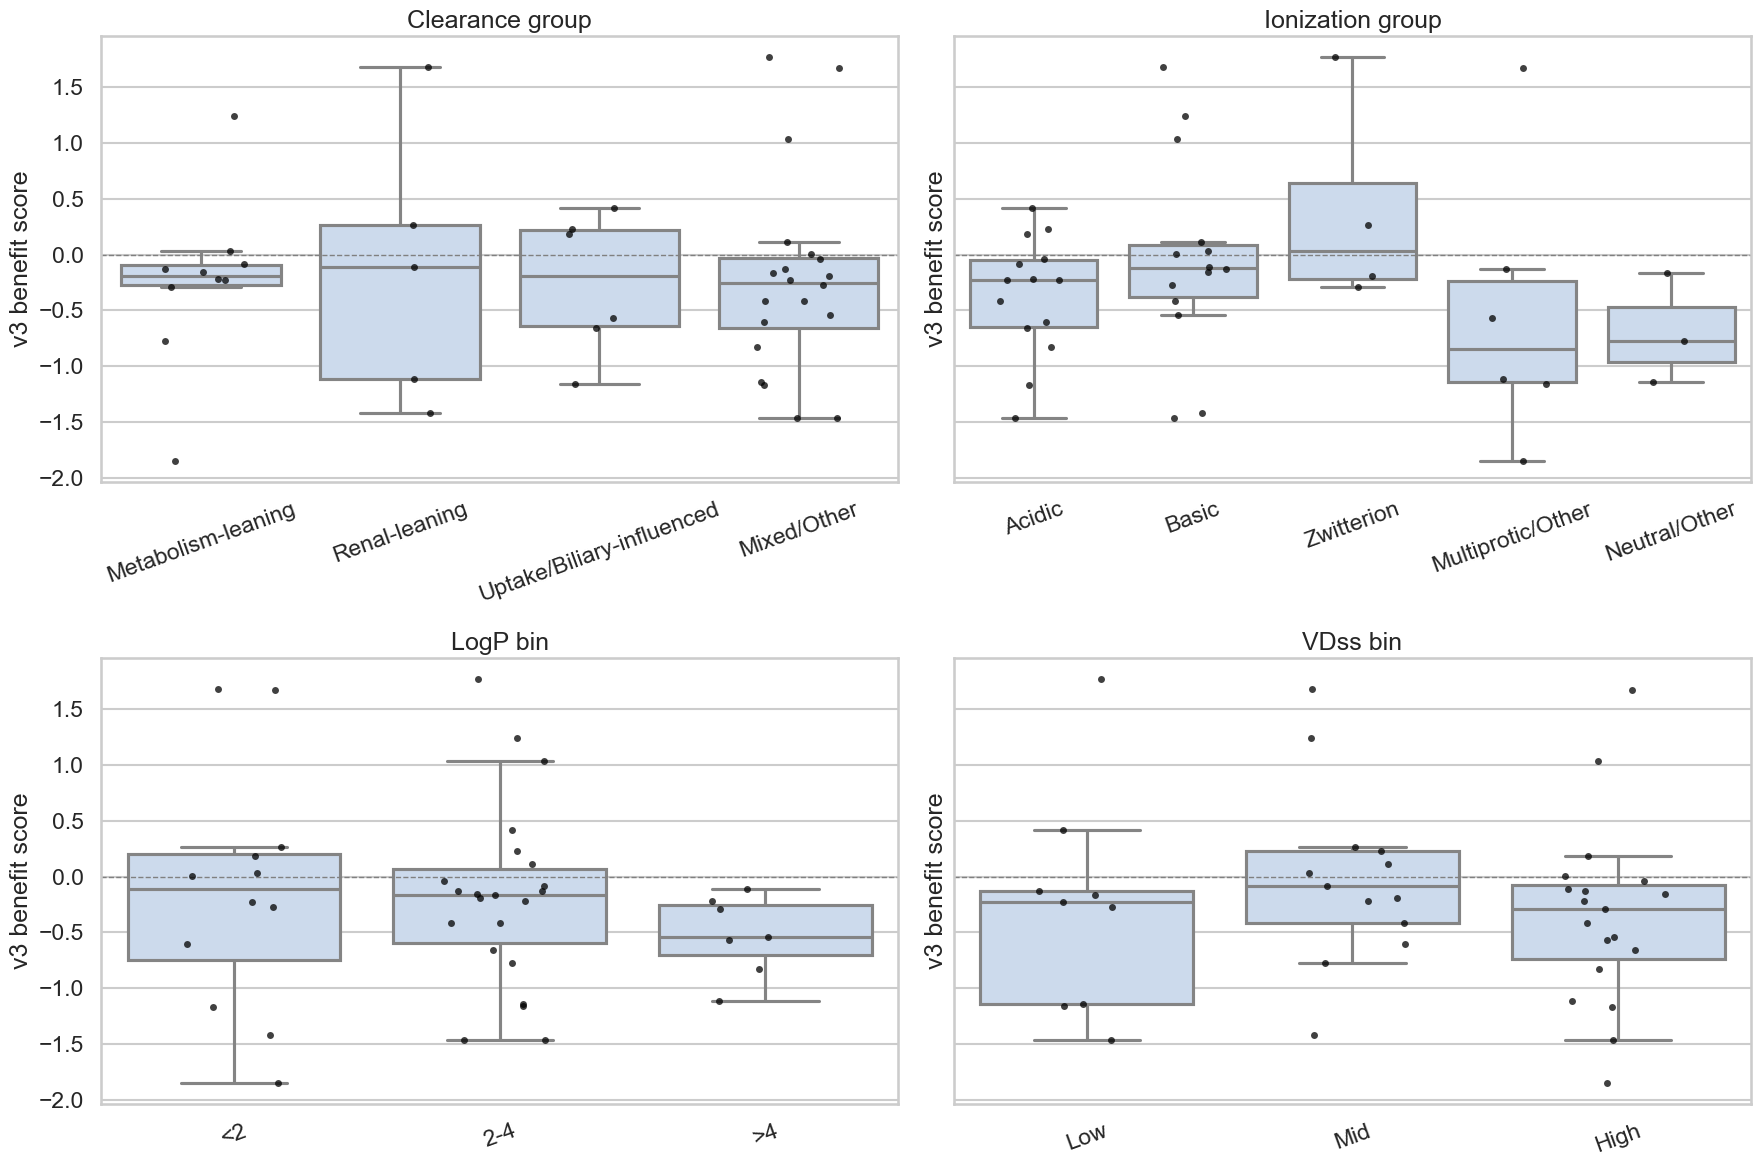

PosixPath('/Users/clement.cai/Documents/New project/Table3_data/pbpk evaluation repo/evaluation/Table3/plot/mechanistic/Response_Figure_R4_benefit_by_mechanistic_strata.png')

In [36]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12), sharey=True)
for ax, (col, order, title) in zip(axes.flat, group_specs):
    sns.boxplot(data=master, x=col, y=BENEFIT_SCORE_CONC, order=order, ax=ax, color="#c7d9f1", fliersize=0)
    sns.stripplot(data=master, x=col, y=BENEFIT_SCORE_CONC, order=order, ax=ax, color="black", size=5, alpha=0.75, jitter=0.22)
    ax.axhline(0, ls="--", c="gray", lw=1)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("v3 benefit score")
    ax.tick_params(axis="x", rotation=20)
plt.tight_layout()

out_base = MECH_PLOT_DIR / "Response_Figure_R4_benefit_by_mechanistic_strata"
fig.savefig(out_base.with_suffix(".png"), dpi=600, bbox_inches="tight")
fig.savefig(out_base.with_suffix(".pdf"), bbox_inches="tight")
plt.show()

plt.close(fig)

out_base.with_suffix(".png")


### Export Mechanistic Summary Tables

The following compact tables are exported for auditability. They summarize outcome counts and median benefit scores by simplified ECCS class and by empirical mechanistic strata.


In [32]:
summary_dir = REPO_ROOT / "evaluation" / "Table3" / "mechanistic_summary"
summary_dir.mkdir(parents=True, exist_ok=True)

pd.crosstab(master["ECCS_new"], master["class"], dropna=False).reindex(index=eccs_new_order, columns=class_order).to_csv(
    summary_dir / "class_by_ECCS_new.csv"
)

benefit_summary = master.groupby("ECCS_new", observed=False).agg(
    n=("PUBCHEM_CID", "count"),
    median_benefit_conc=(BENEFIT_SCORE_CONC, "median"),
    median_benefit_cmax=(BENEFIT_SCORE_CMAX, "median"),
    median_benefit_auc=(BENEFIT_SCORE_AUC, "median"),
).reindex(eccs_new_order)
benefit_summary.to_csv(summary_dir / "benefit_scores_by_ECCS_new.csv")

for col, order, _ in group_specs:
    pd.crosstab(master[col], master["class"], dropna=False).reindex(index=order, columns=class_order).to_csv(
        summary_dir / f"class_by_{col}.csv"
    )

benefit_summary


,n,median_benefit_conc,median_benefit_cmax,median_benefit_auc
ECCS_new,,,,
Class1,6,-0.5505,-0.8304,-0.6201
Class2,22,-0.2246,-0.1108,-0.3617
Class3,6,0.2460,0.0700,-0.0304
Class4,5,0.1859,-0.6805,0.5309
